# Model Training

#### 1.1 Importing Data & Required Packages

In [5]:
## Basic Imports:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Modeling:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV


#### Import the CSV as DataFrame

In [3]:
df=pd.read_csv("data/StudPerf.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing Independent & Dependent Feature Variables

In [22]:
X=df.drop('math score',axis=1) ## Independent Features (Inputs)
y=df['math score'] ## Dependent Feature (Output)

In [23]:
X

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


#### 1.2 Standardization & Encoding

In [24]:
## Creating Column Tranformers:
numeric_cols=X.select_dtypes(exclude="str").columns
cat_cols=X.select_dtypes(include="str").columns

numeric_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("StandardScaler",numeric_transformer,numeric_cols),
        ("OneHotEncoder",cat_transformer,cat_cols)
    ]
)

#### 1.3 Train-Test Split

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [27]:
X_train.shape,X_test.shape

((800, 19), (200, 19))

#### 1.4 Model Training

##### Create an Evaluation Function which evalutes Model's different Metrics

In [28]:
def evaluate_model(true,predicted):
    mse=mean_squared_error(true,predicted)
    rmse=root_mean_squared_error(true,predicted)
    R2_score=r2_score(true,predicted)
    
    return mse,rmse,R2_score

In [29]:
models={
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge':Ridge(),
    'Support Vectors': SVR(),
    'K Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Ada Boost': AdaBoostRegressor(),
    'XG Boost': XGBRegressor()
}
model_list=[]
r2_list=[]

for i in range (len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    
    train_mse,train_rmse,train_r2_score=evaluate_model(y_train,y_train_pred)
    test_mse,test_rmse,test_r2_score=evaluate_model(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("Model Performance For Training Set")
    print(f"- Root Mean Squared Error: {train_rmse}")
    print(f"- Mean Squared Error: {train_mse}")
    print(f"- R2 Score: {train_r2_score}")
    print("-------------------------------------------------------")
    print("Model Performance For Test Set")
    print(f"- Root Mean Squared Error: {test_rmse}")
    print(f"- Mean Squared Error: {test_mse}")
    print(f"- R2 Score: {test_r2_score}")
    
    r2_list.append(test_r2_score)

    print('='*35)
    print('\n')
    
    

Linear Regression
Model Performance For Training Set
- Root Mean Squared Error: 5.323050852720514
- Mean Squared Error: 28.33487038064859
- R2 Score: 0.8743172040139593
-------------------------------------------------------
Model Performance For Test Set
- Root Mean Squared Error: 5.393993869732841
- Mean Squared Error: 29.095169866715477
- R2 Score: 0.8804332983749565


Lasso
Model Performance For Training Set
- Root Mean Squared Error: 6.59250029865088
- Mean Squared Error: 43.461060187711944
- R2 Score: 0.8072231322208645
-------------------------------------------------------
Model Performance For Test Set
- Root Mean Squared Error: 6.517328221922997
- Mean Squared Error: 42.47556715227398
- R2 Score: 0.8254465092551198


Ridge
Model Performance For Training Set
- Root Mean Squared Error: 5.323320560617112
- Mean Squared Error: 28.337741791088884
- R2 Score: 0.8743044675204545
-------------------------------------------------------
Model Performance For Test Set
- Root Mean Square

#### Results

In [30]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880592
0,Linear Regression,0.880433
7,Ada Boost,0.853065
6,Random Forest,0.846939
1,Lasso,0.825447
8,XG Boost,0.821221
4,K Nearest Neighbors,0.783958
5,Decision Tree,0.735985
3,Support Vectors,0.729105


#### Linear Regression

In [31]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy of the Model: %.2f" %score)


Accuracy of the Model: 88.04


#### Plot y_pred & y_test

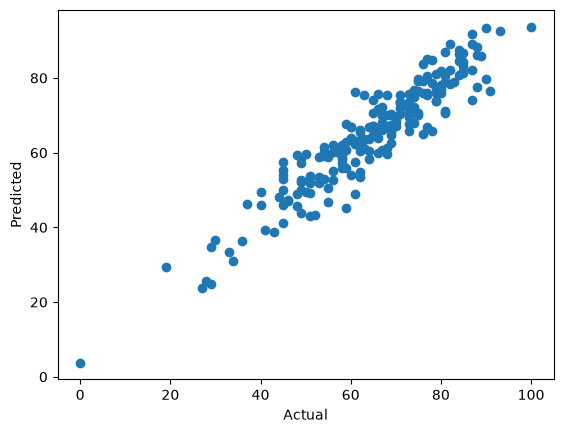

In [32]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

<Axes: xlabel='math score'>

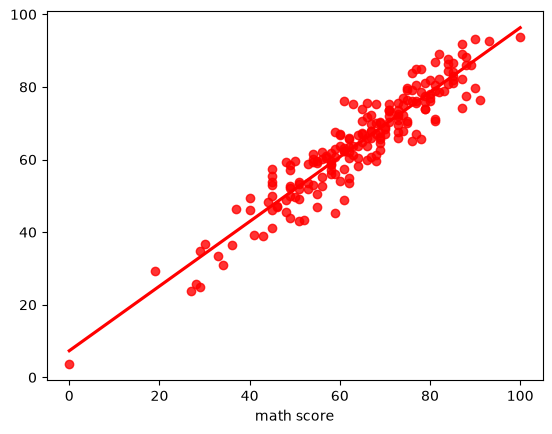

In [33]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

#### Difference between Actual and Predicted Values

In [34]:
df_diff=pd.DataFrame({'Actual':y_test, 'Predicted': y_pred, 'Difference': abs(y_test-y_pred)})
df_diff

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,5.885970
740,80,76.990265,3.009735
660,74,76.851804,2.851804
411,84,87.627378,3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,0.152214
208,74,67.888395,6.111605
613,65,67.022287,2.022287
